# Exploring the simulated data

This notebook walks through the **molecular data** iscc produces, one modality at a time:
bulk DNA, single-cell DNA, single-cell RNA (with scanpy), and Visium spatial transcriptomics
(with squidpy).

Everything runs **inline with the Python API**: we grow one tumor, take a biopsy, and run each
assay in the notebook, reading the results straight off the returned objects — no files, no CLI.
Because iscc knows the **true cell type** of every cell, we annotate the AnnData objects with it
and compare the unsupervised clusters/niches against the ground truth.

In [1]:
%matplotlib inline
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import anndata as ad
import squidpy as sq
from iscc.constants import normal_names
from iscc.tumor.models import GenotypeTumor
from iscc.sample.biopsy.biopsy import Biopsy
from iscc.data import bulkDNA, scDNA, scRNA, Visium

sc.settings.verbosity = 0
CONFIG = os.path.join(os.getcwd(), "example_config.yaml")

# Grow one tumor: its ground truth is the shared source for every assay below.
tumor = GenotypeTumor(config=CONFIG, seed=2)
tumor.grow(n_steps=40, seed=2)
cd = tumor.cell_data
print(f"tumor: {tumor.get_tumor_size()} cells | cell_data: {list(cd.keys())}")

# Ground-truth cell type per cell: cancer, or one of the normal types.
true_type = cd["cell_type"]["cell_id"].astype(str)
def coarse_type(v):
    return v if v in normal_names else "cancer"

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/dask/dataframe/__init__.py:31: FutureWarning: The legacy Dask DataFrame implementation is deprecated and will be removed in a future version. Set the configuration option `dataframe.query-planning` to `True` or None to enable the new Dask Dataframe implementation and silence this warning.
  warnings.warn(


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/anndata/utils.py:429: FutureWarning: Importing read_text from `anndata` is deprecated. Import anndata.io.read_text instead.
  warnings.warn(msg, FutureWarning)


tumor: 9213 cells | cell_data: ['cell_evo', 'cell_snv', 'cell_cnv', 'cell_exp', 'cell_crd', 'cell_type', 'cell_deme', 'cell_rna_vaf', 'cell_wgd', 'cell_gland']


## The ground truth

Before any assay, iscc knows everything: which genes are drivers, and every cell's true SNVs,
copy number, expression, and spatial location. The assays below are noisy, partial views of this.

600 genes | 10 oncogenes, 8 tumour suppressors


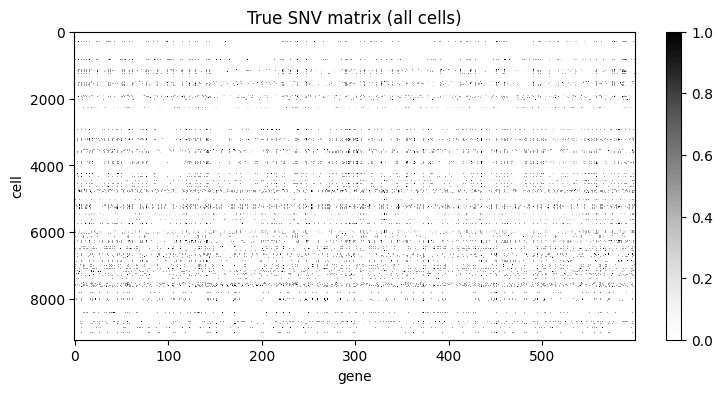

In [2]:
drivers = tumor.get_gene_data()["driver_types"].iloc[:, 0]   # +1 oncogene, -1 TSG, 0 passenger
n_onc = int((drivers == 1).sum()); n_tsg = int((drivers == -1).sum())
print(f"{len(drivers)} genes | {n_onc} oncogenes, {n_tsg} tumour suppressors")

true_snv = cd["cell_snv"]
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(true_snv.values, aspect="auto", cmap="Greys", interpolation="none")
ax.set_xlabel("gene"); ax.set_ylabel("cell"); ax.set_title("True SNV matrix (all cells)")
plt.colorbar(im, ax=ax, fraction=0.046)

## The biopsy sample

A `Biopsy` captures a spatially-realistic subset of cells while preserving their ground truth.
Here we take a **punch** (disk) over the `cell_crd` grid, then slice every ground-truth matrix
down to the chosen cells to get the `sample` the assays will sequence.

punch biopsy: 1859 / 9213 cells | geometry: {'method': 'punch', 'center': [13.300336481059373, 12.582872028655162], 'radius': 6.25}


Text(0.5, 1.0, 'Biopsy: sampled cells')

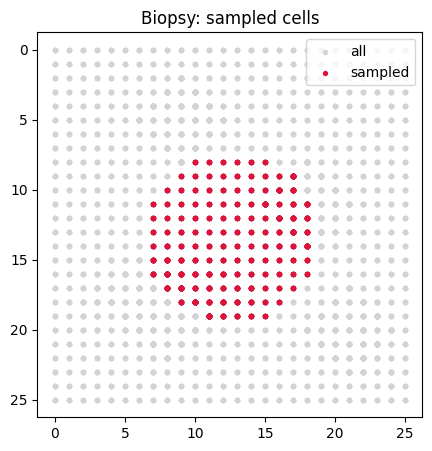

In [3]:
bx = Biopsy(cd, rng=np.random.default_rng(0))
chosen, region, geom = bx.sample(biopsy_type="punch")
sample = {k: df.loc[chosen] for k, df in cd.items()}
print(f"punch biopsy: {len(chosen)} / {len(cd['cell_snv'])} cells | geometry: {geom}")

crd = cd["cell_crd"]
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(crd["col"], crd["row"], s=8, c="lightgrey", label="all")
ax.scatter(crd.loc[chosen, "col"], crd.loc[chosen, "row"], s=8, c="crimson", label="sampled")
ax.set_aspect("equal"); ax.invert_yaxis(); ax.legend(); ax.set_title("Biopsy: sampled cells")

## Bulk DNA-seq

Bulk DNA pools the sampled cells. We get a per-gene coverage and alt-read count, from which we
read out the **variant allele frequency (VAF)** spectrum.

top variant genes: ['G_1_23', 'G_0_46', 'G_9_1', 'G_1_27', 'G_4_5']


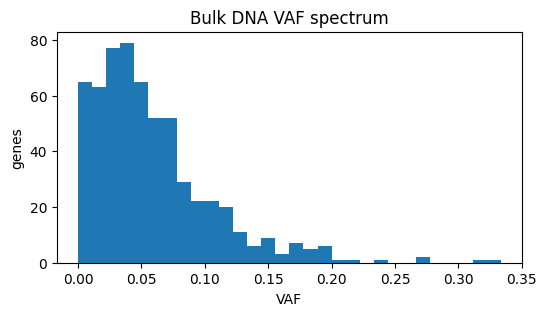

In [4]:
bd = bulkDNA(n_reads=50000, data_mode="counts", fpr=0.02, fnr=0.02)
bd.run(sample)
vaf = bd.observed_data["vaf"][bd.observed_data["coverage"] > 0]   # drop zero-coverage loci
fig, ax = plt.subplots(figsize=(6, 3))
ax.hist(vaf, bins=30); ax.set_xlabel("VAF"); ax.set_ylabel("genes"); ax.set_title("Bulk DNA VAF spectrum")
print("top variant genes:", list(vaf.sort_values(ascending=False).head(5).index))

## Single-cell DNA-seq

scDNA resolves SNVs per cell. We compute a per-cell VAF matrix (alt / coverage) — the substrate
for clone reconstruction.

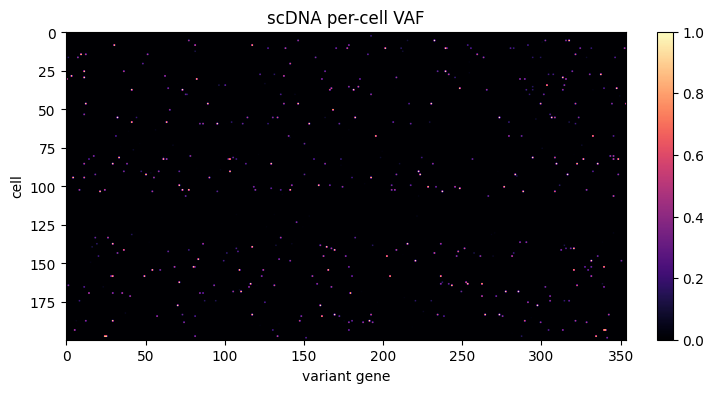

In [5]:
sd = scDNA(n_cells=200, breadth="wgs")
sd.run(sample)
sc_vaf = sd.vaf.fillna(0)
keep = sc_vaf.columns[sc_vaf.sum(0) > 0]   # genes with any signal
fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(sc_vaf[keep].values, aspect="auto", cmap="magma")
ax.set_xlabel("variant gene"); ax.set_ylabel("cell"); ax.set_title("scDNA per-cell VAF")
plt.colorbar(im, ax=ax, fraction=0.046)

## Single-cell RNA-seq

scRNA gives UMI counts per cell. We turn the assay into an `AnnData` with `sr.to_anndata()`,
**annotate each cell with its true type** (`adata.obs['cell_type']`), then run a standard scanpy
workflow: QC, normalization, PCA, neighbours, Leiden clustering and UMAP. Colouring the UMAP by
the true cell type shows how well the unsupervised clusters recover it.

In [6]:
sr = scRNA(n_reads=4000, n_cells=400)
sr.run(sample)
adata = sr.to_anndata()
# ground-truth cell-type annotation
adata.obs["cell_type"] = pd.Categorical(true_type.reindex(adata.obs_names).map(coarse_type))
sc.pp.calculate_qc_metrics(adata, inplace=True, percent_top=None)
sc.pp.filter_genes(adata, min_cells=3)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.pca(adata, n_comps=20)
sc.pp.neighbors(adata, n_neighbors=15)
sc.tl.leiden(adata, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
sc.tl.umap(adata)
print("cell-type annotations:", dict(adata.obs["cell_type"].value_counts()))

/Users/pedroferreira/miniconda3/envs/iscc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


cell-type annotations: {'stromal': 171, 'cancer': 148, 'epithelial': 81}


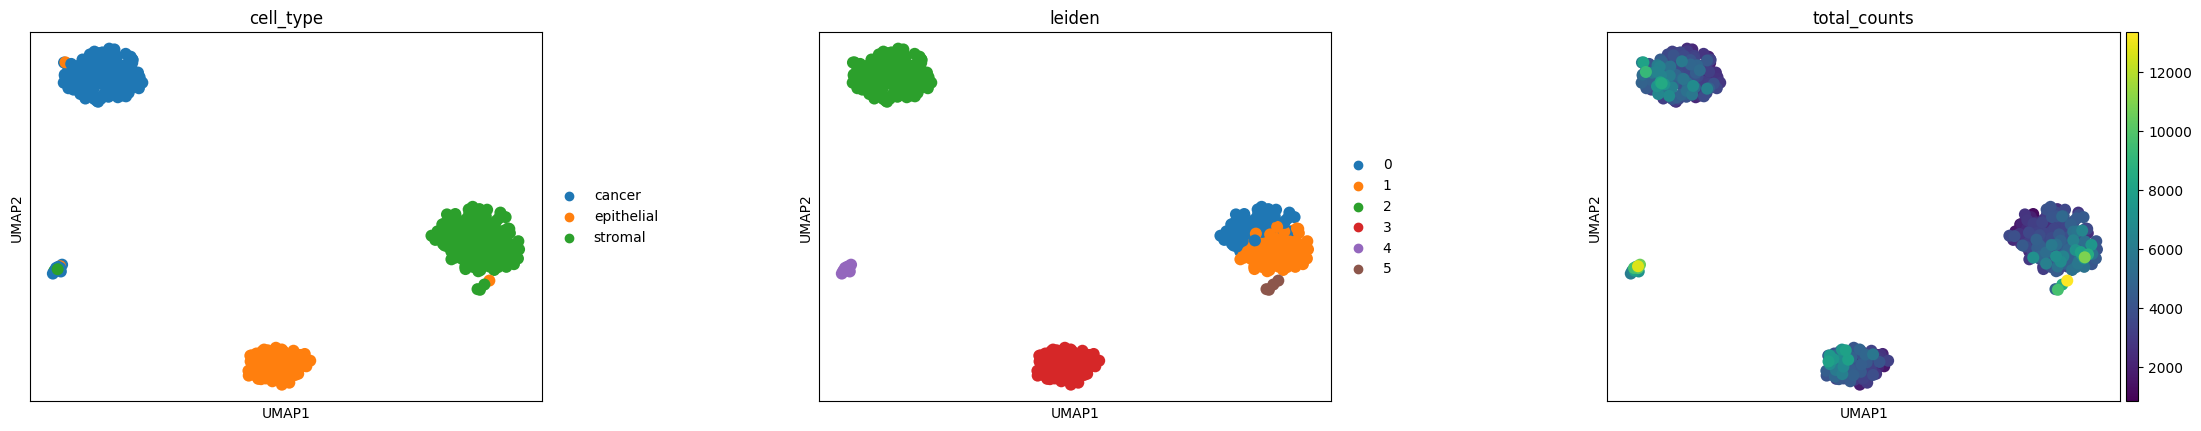

In [7]:
sc.pl.umap(adata, color=["cell_type", "leiden", "total_counts"], wspace=0.4)

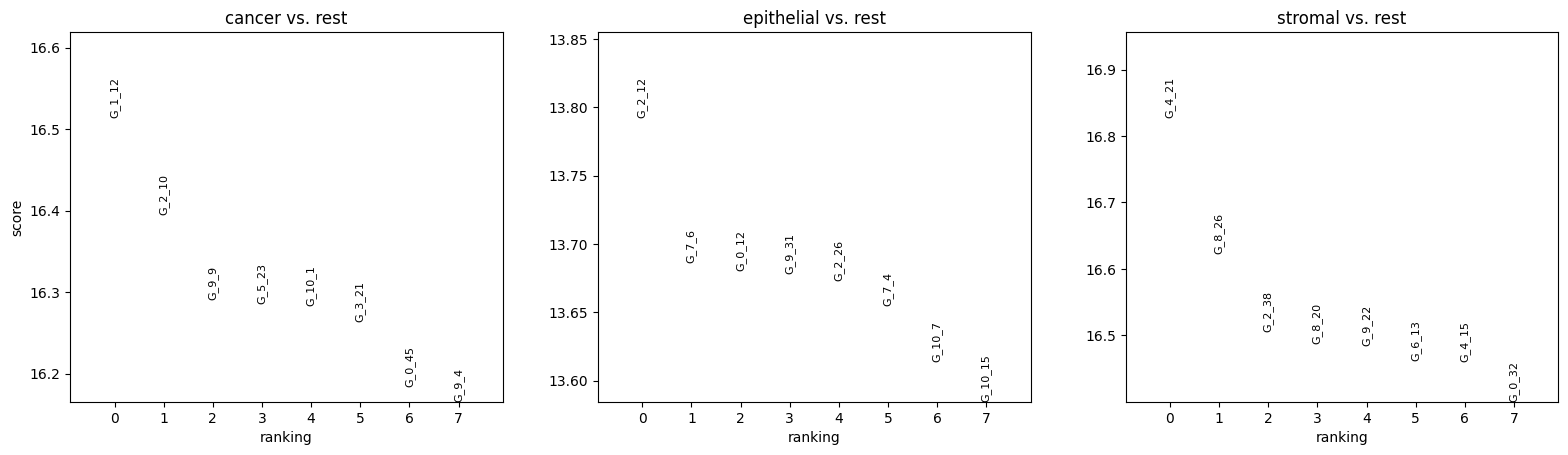

In [8]:
sc.tl.rank_genes_groups(adata, groupby="cell_type", method="wilcoxon")
sc.pl.rank_genes_groups(adata, n_genes=8, sharey=False)

## Visium spatial transcriptomics

Visium pools cells into spatial spots. We run it on the **whole tumor** `cd` (spatial context
matters, so this section does not use the biopsy), build an `AnnData` with `vz.to_anndata()`,
annotate each spot with its **dominant true cell type** (from `vz.spot_members`, the cells that
fall in it), cluster the spots into niches, and use squidpy to build a spatial neighbour graph.

In [9]:
grid_side = int(cd["cell_crd"].max().max()) + 1
vz = Visium(n_reads=4000, spot_radius=1.5)
vz.run(cd, grid_side=grid_side)      # spatial section runs on the whole tumor, not the biopsy

def dominant_type(members):
    types = [coarse_type(true_type.get(str(c), "cancer")) for c in members]
    return pd.Series(types).mode().iloc[0] if types else "empty"

vis = vz.to_anndata()                                        # X = spots x genes, obsm["spatial"]
vis.obs["cell_type"] = pd.Categorical([dominant_type(m) for m in vz.spot_members])
sc.pp.filter_cells(vis, min_counts=1)        # drop empty spots
sc.pp.normalize_total(vis); sc.pp.log1p(vis)
sc.pp.pca(vis, n_comps=20); sc.pp.neighbors(vis)
sc.tl.leiden(vis, resolution=1.0, flavor="igraph", n_iterations=2, directed=False)
sq.gr.spatial_neighbors(vis, coord_type="generic", n_neighs=6)
print("dominant spot types:", dict(vis.obs["cell_type"].value_counts()))

dominant spot types: {'stromal': 122, 'cancer': 29, 'epithelial': 24}


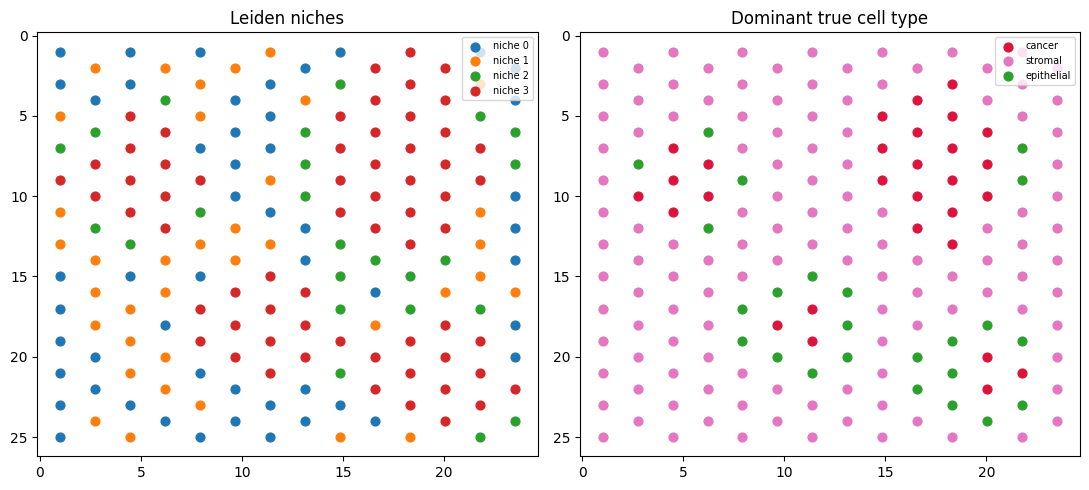

In [10]:
colors = {"cancer": "crimson", "stromal": "tab:pink", "epithelial": "tab:green",
          "immune": "gold", "empty": "lightgrey"}
sp = vis.obsm["spatial"]
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
# left: niches (unsupervised), right: dominant true cell type
for cl in sorted(vis.obs["leiden"].unique(), key=int):
    m = (vis.obs["leiden"] == cl).values
    axes[0].scatter(sp[m, 0], sp[m, 1], s=40, label=f"niche {cl}")
axes[0].set_title("Leiden niches"); axes[0].legend(fontsize=7)
for ct, col in colors.items():
    m = (vis.obs["cell_type"] == ct).values
    if m.any():
        axes[1].scatter(sp[m, 0], sp[m, 1], s=40, c=col, label=ct)
axes[1].set_title("Dominant true cell type"); axes[1].legend(fontsize=7)
for ax in axes:
    ax.invert_yaxis()
plt.tight_layout()

## Recap

We took one simulated tumor and viewed it through bulk DNA, scDNA, scRNA and Visium — each a
noisy, partial measurement of the same ground truth. Because the ground truth (each cell's true
type, clone, copy number and mutations) is known, these datasets are ideal benchmarks for
tumor-evolution methods.

The assays model realistic technical structure — negative-binomial + dropout scRNA,
allele-specific single-cell DNA with allelic dropout, a read/FASTQ mode, and spatial spot mixing
with autocorrelation — and their parameters can be fit to real reference data. Further
analysis-demo notebooks (MHN from DNA, niche identification, batch effects, combining modalities,
real-data comparison) build on these datasets.